# Task 01

In [1]:
# Install required libraries
!pip install requests beautifulsoup4 pandas

In [3]:
# Import all necessary libraries
import requests                       
from bs4 import BeautifulSoup          
import pandas as pd                    
import time                            

In [4]:
# Base URL of the website we are scraping
# books.toscrape.com is a safe practice website made for scraping
base_url = "http://books.toscrape.com/catalogue/page-{}.html"

# Empty list to store all book data
all_books = []

# Rating words to numbers mapping
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

print("Setup complete! Ready to scrape...")

Setup complete! Ready to scrape...


# Scraping Function

In [5]:
def scrape_books(page_number):
    """
    Function to scrape book data from a single page
    Returns a list of book dictionaries
    """
    
    # Format the URL with the page number
    url = base_url.format(page_number)
    
    # Set headers to mimic a real browser request
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    # Send HTTP GET request to the website
    response = requests.get(url, headers=headers)
    
    # Check if request was successful (status code 200 = OK)
    if response.status_code != 200:
        print(f"  Failed to fetch page {page_number}. Status code: {response.status_code}")
        return []
    
    # Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all book containers on the page
    books = soup.find_all('article', class_='product_pod')
    
    page_books = []
    
    for book in books:
        # Extract book title from the anchor tag's title attribute
        title = book.find('h3').find('a')['title']
        
        # Extract price and remove currency symbol
        price = book.find('p', class_='price_color').text.strip()
        price_clean = float(price.replace('£', '').replace('Â', ''))
        
        # Extract star rating (stored as word in CSS class)
        rating_word = book.find('p', class_='star-rating')['class'][1]
        rating = rating_map.get(rating_word, 0)
        
        # Extract availability status
        availability = book.find('p', class_='availability').text.strip()
        
        # Extract individual book page URL for more details
        book_url = "http://books.toscrape.com/catalogue/" + book.find('h3').find('a')['href']
        
        # Store all extracted data in a dictionary
        page_books.append({
            'Title': title,
            'Price (£)': price_clean,
            'Rating (out of 5)': rating,
            'Availability': availability,
            'Book URL': book_url
        })
    
    return page_books

print("Function defined successfully!")

Function defined successfully!


# Run Scraper

In [6]:
# Scrape first 10 pages (each page has 20 books = 200 books total)
total_pages = 10

print(f"Starting to scrape {total_pages} pages...")
print("-" * 50)

for page in range(1, total_pages + 1):
    print(f"Scraping page {page}/{total_pages}...", end=" ")
    
    # Call our scraping function for each page
    books_on_page = scrape_books(page)
    
    # Add the results to our main list
    all_books.extend(books_on_page)
    
    print(f"Found {len(books_on_page)} books")
    
    # Wait 1 second between requests to be polite to the server
    time.sleep(1)

print("-" * 50)
print(f"Scraping complete! Total books collected: {len(all_books)}")

Starting to scrape 10 pages...
--------------------------------------------------
Scraping page 1/10... Found 20 books
Scraping page 2/10... Found 20 books
Scraping page 3/10... Found 20 books
Scraping page 4/10... Found 20 books
Scraping page 5/10... Found 20 books
Scraping page 6/10... Found 20 books
Scraping page 7/10... Found 20 books
Scraping page 8/10... Found 20 books
Scraping page 9/10... Found 20 books
Scraping page 10/10... Found 20 books
--------------------------------------------------
Scraping complete! Total books collected: 200


# Save to CSV

In [7]:
# Convert list of dictionaries to a pandas DataFrame
df = pd.DataFrame(all_books)

# Save the DataFrame to a CSV file
df.to_csv('books_data.csv', index=False, encoding='utf-8')

print("Data saved to 'books_data.csv' successfully!")
print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 books:")
print(df.head())

Data saved to 'books_data.csv' successfully!

Dataset Shape: 200 rows x 5 columns

First 5 books:
                                   Title  Price (£)  Rating (out of 5)  \
0                   A Light in the Attic      51.77                  3   
1                     Tipping the Velvet      53.74                  1   
2                             Soumission      50.10                  1   
3                          Sharp Objects      47.82                  4   
4  Sapiens: A Brief History of Humankind      54.23                  5   

  Availability                                           Book URL  
0     In stock  http://books.toscrape.com/catalogue/a-light-in...  
1     In stock  http://books.toscrape.com/catalogue/tipping-th...  
2     In stock  http://books.toscrape.com/catalogue/soumission...  
3     In stock  http://books.toscrape.com/catalogue/sharp-obje...  
4     In stock  http://books.toscrape.com/catalogue/sapiens-a-...  


# Basic Analysis

In [8]:
# Quick analysis of scraped data

print("=" * 50)
print("BASIC DATA ANALYSIS")
print("=" * 50)

# Show data types and info
print("\nDataset Info:")
print(df.info())

# Show summary statistics for numerical columns
print("\nSummary Statistics:")
print(df.describe())

# Most expensive books
print("\nTop 5 Most Expensive Books:")
print(df.nlargest(5, 'Price (£)')[['Title', 'Price (£)', 'Rating (out of 5)']])

# Cheapest books
print("\nTop 5 Cheapest Books:")
print(df.nsmallest(5, 'Price (£)')[['Title', 'Price (£)', 'Rating (out of 5)']])

# Rating distribution
print("\nBooks by Rating:")
print(df['Rating (out of 5)'].value_counts().sort_index())

BASIC DATA ANALYSIS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              200 non-null    object 
 1   Price (£)          200 non-null    float64
 2   Rating (out of 5)  200 non-null    int64  
 3   Availability       200 non-null    object 
 4   Book URL           200 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 7.9+ KB
None

Summary Statistics:
        Price (£)  Rating (out of 5)
count  200.000000         200.000000
mean    34.796250           2.865000
std     14.119272           1.451658
min     10.160000           1.000000
25%     21.990000           2.000000
50%     35.640000           3.000000
75%     46.110000           4.000000
max     59.640000           5.000000

Top 5 Most Expensive Books:
                                                 Title  Price (£)  \
133  T

# Visualize Data

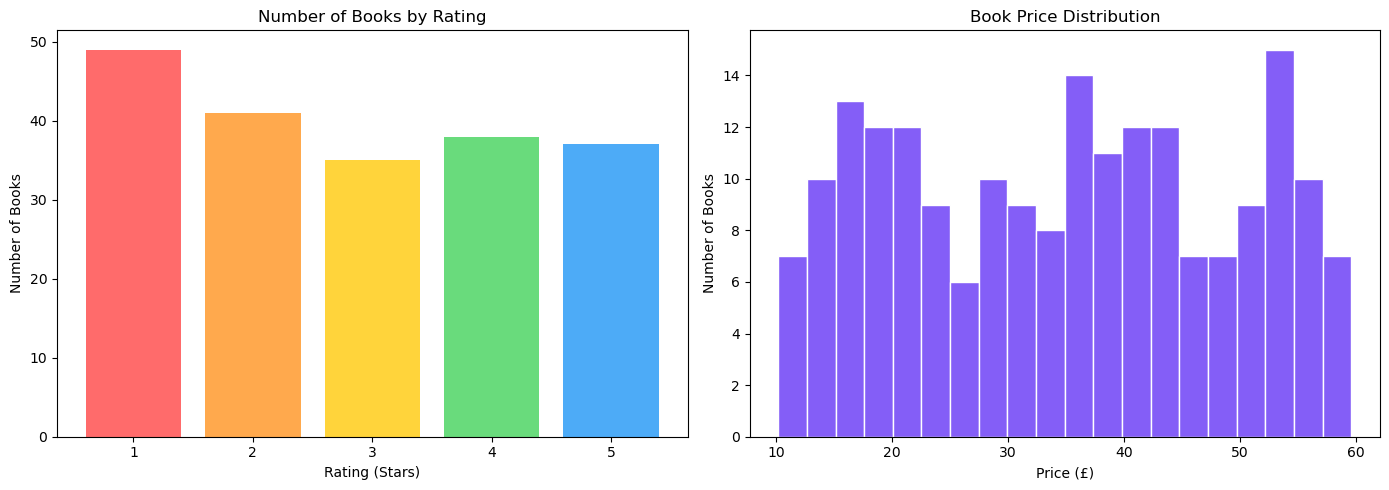

Chart saved as 'books_analysis.png'


In [9]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Rating Distribution ---
rating_counts = df['Rating (out of 5)'].value_counts().sort_index()
axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=['#ff6b6b', '#ffa94d', '#ffd43b', '#69db7c', '#4dabf7']
)
axes[0].set_title('Number of Books by Rating')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Number of Books')
axes[0].set_xticks([1, 2, 3, 4, 5])

# --- Chart 2: Price Distribution ---
axes[1].hist(
    df['Price (£)'],
    bins=20,
    color='#845ef7',
    edgecolor='white'
)
axes[1].set_title('Book Price Distribution')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Number of Books')

plt.tight_layout()
plt.savefig('books_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as 'books_analysis.png'")